# High Fidelity Neural Network
Neural Network which uses HF dataset and exploits the High fidelity component of the MF model  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions_noise_fourier import (
    getModel,
    kCrossVal,
    transfBestparam,
    kCrossValSingle,
    import_data, normalization
)
from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf



In [2]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data preparation

In [3]:
file_path_HF = "../../Diffusion/DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[-1,: , 44,44]
# ATTENTION: here reaction_HF_test is a time parameter (the name is kept not to find issues)
NepoHF = 250  # number of epochs for second NN: NN_HF

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = normalization(U_HF_test)
reaction_HF_test_original=np.c_[reaction_HF_test,np.abs(np.sin(8*np.pi*reaction_HF_test[:, 0]))]
U_HF_test_original=U_HF_test

noise_stddev2 = 0.01       # value?
noise2 = np.random.normal(0, noise_stddev2, U_HF_test.shape[0])
noise_stddev3 = 0.005       # value?
noise3 = np.random.normal(0, noise_stddev3, U_HF_test.shape[0])
U_HF_noise2 = U_HF_test + noise2
U_HF_noise3 = U_HF_test + noise3

noise_stddev4 = 0.02       # value?
noise4 = np.random.normal(0, noise_stddev4, U_HF_test.shape[0])
noise_stddev5 = 0.005       # value?
noise5 = np.random.normal(0, noise_stddev5, U_HF_test.shape[0])
U_HF_noise4 = U_HF_test + noise4
U_HF_noise5 = U_HF_test + noise5



U_HF_test = np.concatenate((U_HF_test, U_HF_noise2,U_HF_noise3,U_HF_noise4,U_HF_noise5),axis=0)


noise_stddev2 = 0.00025       # value?
noise2 = np.random.normal(0, noise_stddev2, reaction_HF_test.shape)
noise_stddev3 = 0.00015       # value?
noise3 = np.random.normal(0, noise_stddev3, reaction_HF_test.shape)
reaction_HF_noise2 = reaction_HF_test + noise2
reaction_HF_noise3 = reaction_HF_test + noise3

noise_stddev4 = 0.00025       # value?
noise4 = np.random.normal(0, noise_stddev4, reaction_HF_test.shape)
noise_stddev5 = 0.00015       # value?
noise5 = np.random.normal(0, noise_stddev5, reaction_HF_test.shape)
reaction_HF_noise4 = reaction_HF_test + noise4
reaction_HF_noise5 = reaction_HF_test + noise5

reaction_HF_test = np.concatenate((reaction_HF_test, reaction_HF_noise2,reaction_HF_noise3,reaction_HF_noise4,reaction_HF_noise5))
reaction_HF_test=np.c_[reaction_HF_test,np.abs(np.sin(8*np.pi*reaction_HF_test[:, 0]))]


permutation = np.random.permutation(len(reaction_HF_test))
Nhf = 200

reaction_HF = reaction_HF_test[permutation][0:Nhf]
U_HF = U_HF_test[permutation][0:Nhf]


# Neural Network

In [4]:
start = perf_counter()

#reaction_final = np.vstack(
#    (reaction_HF)
#) 

name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()

best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }
                

print(best_params)

{'kernel_init': 'uniform', 'l2weight': 0.0002588943618918075, 'lr': 0.008365144388542751, 'nodes': 6.0, 'opt': 'Adam'}


In [5]:
##########HPO##########

# start = perf_counter()

# reaction_final = np.vstack(
#     (reaction_HF)
# ) 

# MAX_EVAL = 2
# name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
# K.clear_session()
# bayes_trials = Trials()
# opt_list = ["Adam", "Adamax"]
# kernel_list = ["uniform", "glorot_uniform"]
# aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
# space = {
#     "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
#     "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
#     "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
#     "kernel_init": hp.choice("kernel_init", kernel_list),
#     "opt": hp.choice("opt", opt_list),
# }


# def objective(params):
#     K.clear_session()
#     CVres = kCrossValSingle(Nhf, NepoHF, reaction_final, U_HF, params, name)
#     return {"loss": CVres, "params": params, "status": STATUS_OK}


# best_params = fmin(
#     fn=objective,
#     space=space,
#     algo=tpe.suggest,
#     max_evals=MAX_EVAL,
#     trials=bayes_trials,
# )

# transfBestparam(best_params, aux_dic)
# print(best_params)


In [6]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()

finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_HF,
    U_HF,
    validation_data=(reaction_HF_test_original, U_HF_test_original),
    epochs=NepoHF,
    batch_size=Nhf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_HF_test_original)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nHF Model:")
test_mse = np.mean(np.square(U_HF_test_original - UHF[:, 0]))
print(f"Test MSE: {test_mse}")
test_mae=np.mean(np.abs(U_HF_test_original - UHF[:, 0]))
test_rmse=np.sqrt(np.mean((U_HF_test_original - UHF[:, 0])**2))
print(f"Test MAE: {test_mae}")
print(f"Test RMSE: {test_rmse}")


r2_HF = 1 - np.sum(np.square(U_HF_test_original - UHF[:, 0])) / np.sum(
    np.square(U_HF_test_original - np.mean(U_HF_test_original))
)
print(f"R^2: {r2_HF}")

26/26 [==============================] - 0s 1ms/step
Elapsed time:  23.050886699929833

HF Model:
Elapsed time:  22.676086999941617

HF Model:
Test MSE: 0.10887023173387508
Test MAE: 0.29561181328204544
Test RMSE: 0.32995489348375345
R^2: -0.012649004579544432


# POST PROCESSING

26/26 [==============================] - 0s 2ms/step


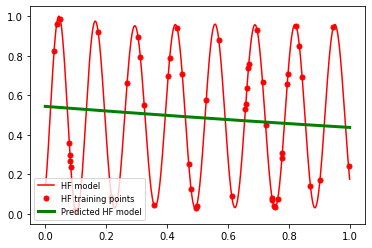

In [7]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model")
plt.plot(reaction_HF[:,0], U_HF, "ro", markersize=5, label="HF training points")
plt.plot(
    reaction_HF_test_original[:,0],
    finalModel.predict(reaction_HF_test_original),
    "g-",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

In [8]:
########################     SAVE the OUTPUT      ##########################

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! change the name of the new folder !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
os.makedirs("NNHF_HF_50_3000steps_new_activation")

R2_HF = pandas.DataFrame({"R2_HF": [r2_HF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [test_mse]})


# R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv(
    "./NNHF_HF_50_3000steps_new_activation/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNHF_HF_50_3000steps_new_activation/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
